https://medium.com/@seelcs12/cnns-for-imbalanced-image-classification-with-tensorflow-7284a8c4a2e4

https://medium.com/x8-the-ai-community/solving-class-imbalance-problem-in-cnn-9c7a5231c478

https://github.com/sergiovirahonda/TweetsSentimentAnalysis/blob/main/TweetsSentimentPredictions.ipynb

In [76]:
import tensorflow as tf
from tensorflow.keras import datasets, layers, models
import matplotlib.pyplot as plt
import numpy as np
from tensorflow.keras.metrics import F1Score

(x_train, y_train), (x_test, y_test) = datasets.cifar10.load_data()

# Normalize pixel values to be between 0 and 1
x_train, x_test = x_train / 255.0, x_test / 255.0

In [77]:
# Changing the data labels into binary for a chosen class in the dataset. Here we have chosen frogs, and all the labels who is not a
# a frog will be 0 and vice verse if it is a frog.
num_class = 6

for n in range(len(y_train)):
    if y_train[n] == [num_class]:
        y_train[n] = [1]
    else:
        y_train[n] = [0]

for n in range(len(y_test)):
    if y_test[n] == [num_class]:
        y_test[n] = [1]
    else:
        y_test[n] = [0]

In [78]:
x_tr_frog = []
y_tr_frog = []
for n in range(len(y_train)):
    if y_train[n] == [1]:
        x_tr_frog.append(x_train[n])
        y_tr_frog.append([1])

for n in range(len(y_train)):
    if len(x_tr_frog) < 10000:
        x_tr_frog.append(x_train[n])
        y_tr_frog.append([0])

x_te_frog = []
y_te_frog = []
for n in range(len(y_test)):
    if y_test[n] == [1]:
        x_te_frog.append(x_test[n])
        y_te_frog.append([1])

for n in range(len(y_test)):
    if len(x_te_frog) < 2000:
        x_te_frog.append(x_test[n])
        y_te_frog.append([0])

x_tr_frog = np.array(x_tr_frog)
y_tr_frog = np.array(y_tr_frog)
x_te_frog = np.array(x_te_frog)
y_te_frog = np.array(y_te_frog)

In [79]:
from tensorflow.keras import callbacks

def make_model(metric, x_train, y_train, x_val, y_val):
    with tf.device('/GPU:0'):
        model = models.Sequential()
        model.add(layers.Conv2D(32, (3, 3), activation='relu', input_shape=(32, 32, 3)))
        model.add(layers.BatchNormalization())
        model.add(layers.MaxPooling2D((2, 2)))

        model.add(layers.Conv2D(128, (3, 3), activation='relu'))
        model.add(layers.BatchNormalization())
        model.add(layers.MaxPooling2D((2, 2)))

        model.add(layers.Conv2D(256, (3, 3), activation='relu'))
        model.add(layers.BatchNormalization())

        model.add(layers.Flatten())
        model.add(layers.Dense(128, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.005)))
        model.add(layers.Dropout(0.4))
        model.add(layers.Dense(256, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.005)))
        model.add(layers.Dropout(0.4))
        model.add(layers.Dense(1, activation='sigmoid'))

        model.compile(optimizer='adam', loss='binary_crossentropy', metrics=[metric])

        early_stopping = callbacks.EarlyStopping(monitor='val_loss', patience = 5, restore_best_weights = True)

        history = model.fit(
            x_train,
            y_train,
            batch_size = 32,
            epochs = 10,
            validation_data = (x_val, y_val),
            callbacks = [early_stopping]
        )
        return history, model

In [80]:
acc_history, acc_model = make_model('accuracy', x_tr_frog, y_tr_frog, x_te_frog, y_te_frog)

low_th, medium_th, high_th = 0.25, 0.5, 0.75

f1_low_history, f1_low_model = make_model(F1Score(threshold=low_th, average='micro'), x_tr_frog, y_tr_frog, x_te_frog, y_te_frog)

f1_med_history, f1_med_model = make_model(F1Score(threshold=medium_th, average='micro'), x_tr_frog, y_tr_frog, x_te_frog, y_te_frog)

f1_hi_history, f1_hi_model = make_model(F1Score(threshold=high_th, average='micro'), x_tr_frog, y_tr_frog, x_te_frog, y_te_frog)

Epoch 1/10


c:\Users\dhaaa\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - accuracy: 0.6848 - loss: 2.4781 - val_accuracy: 0.7315 - val_loss: 1.4639
Epoch 2/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - accuracy: 0.7995 - loss: 1.2019 - val_accuracy: 0.7575 - val_loss: 0.8959
Epoch 3/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.8290 - loss: 0.7266 - val_accuracy: 0.7845 - val_loss: 0.6765
Epoch 4/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.8283 - loss: 0.5758 - val_accuracy: 0.8005 - val_loss: 0.6948
Epoch 5/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.8502 - loss: 0.4986 - val_accuracy: 0.8265 - val_loss: 0.5163
Epoch 6/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - accuracy: 0.8645 - loss: 0.4545 - val_accuracy: 0.6820 - val_loss: 0.9589
Epoch 7/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.8641 - loss: 0.4478 - val_accuracy: 0.7670 - val_loss: 0.6246
Epoch 8/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.8762 - loss: 0.4255 - val_accuracy: 0.846

In [81]:
from sklearn.metrics import confusion_matrix

def make_pred(predictions):
    array = []
    for pred in predictions:
        if max(pred) > 0.7:
            array.append([1])
        else:
            array.append([0])
    return np.array(array)

y_pred_acc = acc_model.predict(x_te_frog)
y_pred_acc = make_pred(y_pred_acc)
acc_cf = confusion_matrix(y_te_frog, y_pred_acc)
y_pred_f1_low = f1_low_model.predict(x_te_frog)
y_pred_f1_low = make_pred(y_pred_f1_low)
f1_cf_low = confusion_matrix(y_te_frog, y_pred_f1_low)
y_pred_f1_med = f1_med_model.predict(x_te_frog)
y_pred_f1_med = make_pred(y_pred_f1_med)
f1_cf_med = confusion_matrix(y_te_frog, y_pred_f1_med)
y_pred_f1_hi = f1_hi_model.predict(x_te_frog)
y_pred_f1_hi = make_pred(y_pred_f1_hi)
f1_cf_hi = confusion_matrix(y_te_frog, y_pred_f1_hi)

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step


C:\Users\dhaaa\AppData\Local\Temp\ipykernel_3228\4164175182.py:9: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()
C:\Users\dhaaa\AppData\Local\Temp\ipykernel_3228\4164175182.py:14: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig2.show()


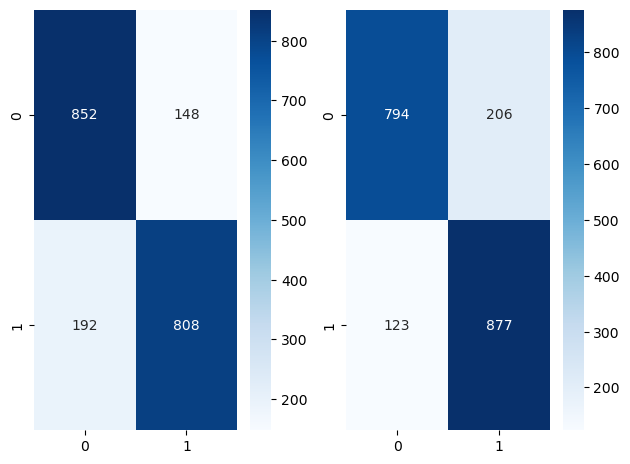

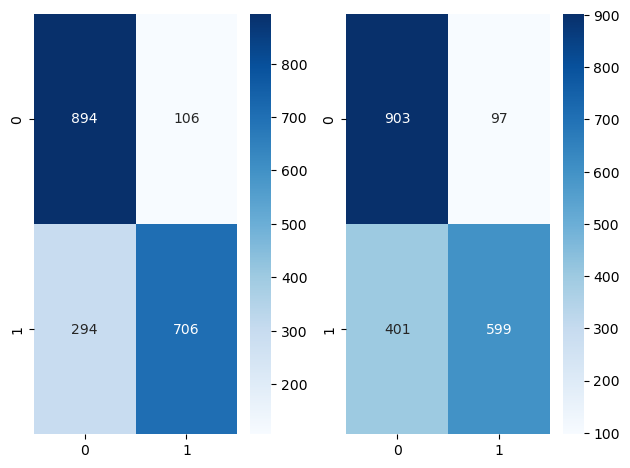

In [82]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

fig, ax = plt.subplots(1,2)
fig.tight_layout()
sns.heatmap(acc_cf, annot=True, cmap='Blues', fmt='d', ax=ax[0])
sns.heatmap(f1_cf_low, annot=True, cmap='Blues', fmt='d', ax=ax[1])
fig.show()
fig2, ax = plt.subplots(1,2)
fig2.tight_layout()
sns.heatmap(f1_cf_med, annot=True, cmap='Blues', fmt='d', ax=ax[0])
sns.heatmap(f1_cf_hi, annot=True, cmap='Blues', fmt='d', ax=ax[1])
fig2.show()

63/63 - 0s - 4ms/step - accuracy: 0.8460 - loss: 0.4958


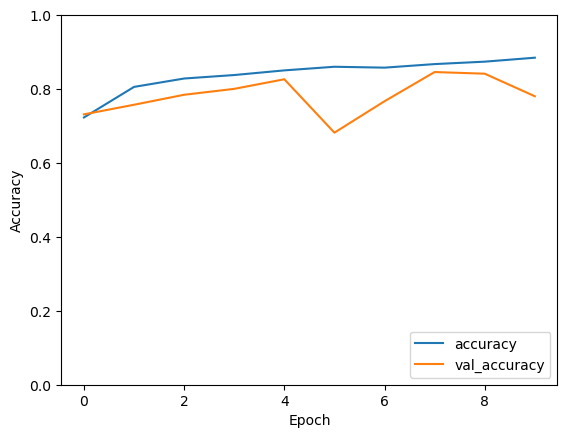

In [83]:
plt.plot(acc_history.history['accuracy'], label='accuracy')
plt.plot(acc_history.history['val_accuracy'], label = 'val_accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.ylim([0.0, 1])
plt.legend(loc='lower right')

test_loss, test_acc = acc_model.evaluate(x_te_frog, y_te_frog, verbose=2)

63/63 - 0s - 5ms/step - f1_score: 0.8161 - loss: 0.5136


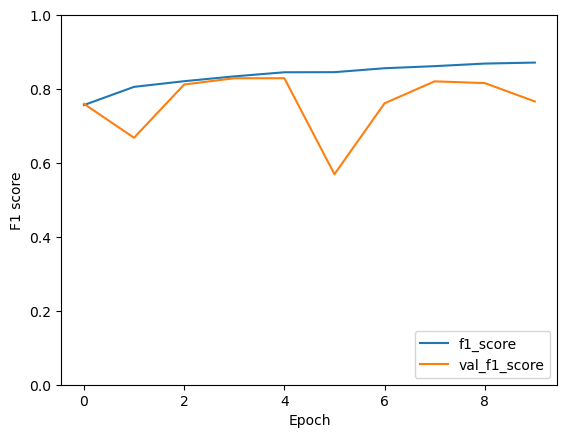

In [84]:
plt.plot(f1_low_history.history['f1_score'], label='f1_score')
plt.plot(f1_low_history.history['val_f1_score'], label = 'val_f1_score')
plt.xlabel('Epoch')
plt.ylabel('F1 score')
plt.ylim([0.0, 1])
plt.legend(loc='lower right')

test_loss, test_acc = f1_low_model.evaluate(x_te_frog, y_te_frog, verbose=2)

63/63 - 0s - 5ms/step - f1_score: 0.8492 - loss: 0.4768


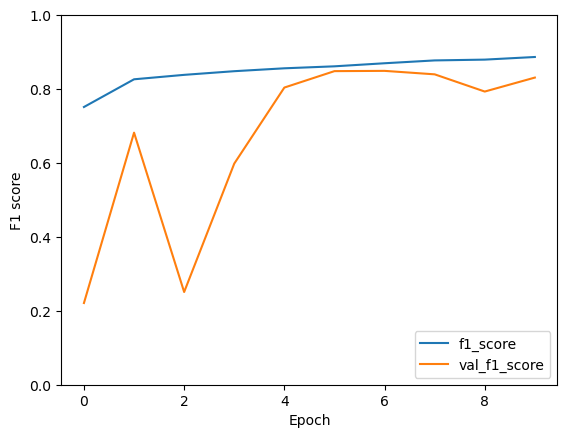

In [85]:
plt.plot(f1_med_history.history['f1_score'], label='f1_score')
plt.plot(f1_med_history.history['val_f1_score'], label = 'val_f1_score')
plt.xlabel('Epoch')
plt.ylabel('F1 score')
plt.ylim([0.0, 1])
plt.legend(loc='lower right')

test_loss, test_acc = f1_med_model.evaluate(x_te_frog, y_te_frog, verbose=2)

63/63 - 0s - 5ms/step - f1_score: 0.5716 - loss: 0.5015


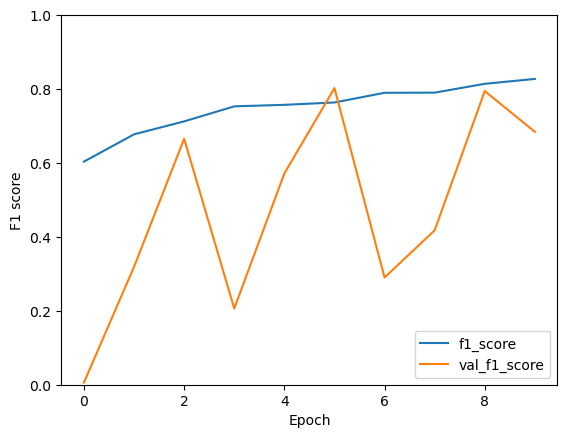

In [86]:
plt.plot(f1_hi_history.history['f1_score'], label='f1_score')
plt.plot(f1_hi_history.history['val_f1_score'], label = 'val_f1_score')
plt.xlabel('Epoch')
plt.ylabel('F1 score')
plt.ylim([0.0, 1])
plt.legend(loc='lower right')

test_loss, test_acc = f1_hi_model.evaluate(x_te_frog, y_te_frog, verbose=2)

In [95]:
img = tf.keras.utils.load_img('./media/frog_3.jpg', target_size=(32, 32))

img_array = tf.keras.utils.img_to_array(img)
img_array = tf.expand_dims(img_array, 0) # Create a batch
img_array = np.array(img_array) / 255.0

prediction = acc_model.predict(img_array)
print(prediction)
if max(prediction) > 0.7:
    print('frog')
else:
    print('not frog')

prediction = f1_low_model.predict(img_array)
print(prediction)
if max(prediction) > 0.7:
    print('frog')
else:
    print('not frog')

prediction = f1_med_model.predict(img_array)
print(prediction)
if max(prediction) > 0.7:
    print('frog')
else:
    print('not frog')

prediction = f1_hi_model.predict(img_array)
print(prediction)
if max(prediction) > 0.7:
    print('frog')
else:
    print('not frog')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
[[0.91222686]]
frog
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
[[0.94530034]]
frog
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
[[0.87087053]]
frog
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
[[0.82297456]]
frog


Accuracy metric: god accuracy, ca. 0.95, lite overfitting, klarer frog med en prediction øve 0.7

F1 score: 